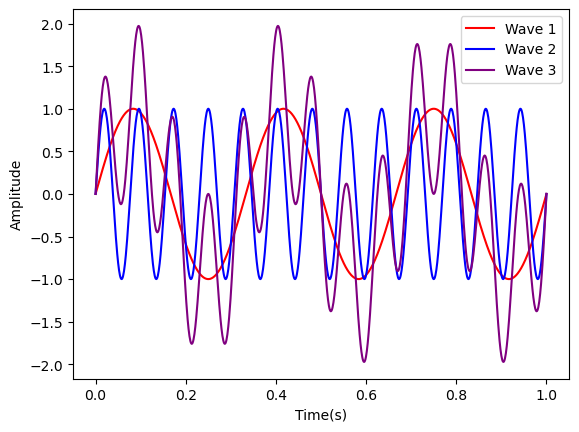

In [34]:
import numpy as np
import math
import matplotlib.pyplot as plt
t = np.linspace(0,1,1000)
wave1 = np.sin(3*2*(math.pi)*t)
wave2 = np.sin(13*2*(math.pi)*t)
wave3clean = wave1 + wave2
plt.plot(t, wave1, label="Wave 1", color="Red")
plt.plot(t, wave2, label="Wave 2", color="Blue")
plt.plot(t, wave3clean, label="Wave 3", color="Purple")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [35]:
import numpy as np
import math

def my_dft(signal):
    N = len(signal)
    X = np.zeros(N, dtype = complex)

    for k in range(N):
        total = 0
        for n in range(N):
            something = signal[n] * np.exp((-1j) * (2 * math.pi) * k * n / N)
            total = total + something
        X[k] = total
            
            
    return X



(-20.0, 20.0)

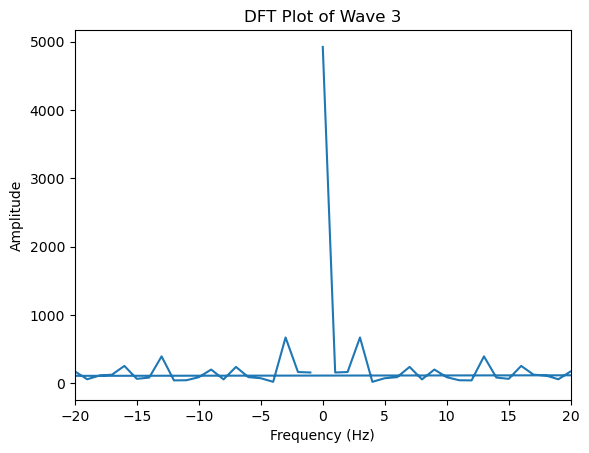

In [36]:
import numpy as np
import math
import matplotlib.pyplot as plt

X = my_dft(wave3)
y = np.fft.fftfreq(1000, .001)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("DFT Plot of Wave 3")
plt.plot(y , np.abs(X))
plt.xlim(-20,20)

(-20.0, 20.0)

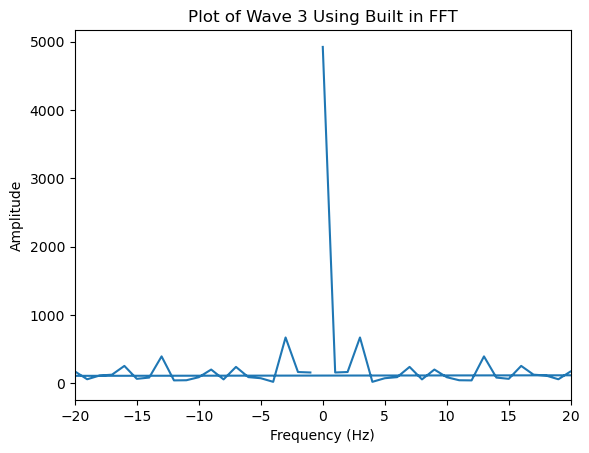

In [37]:
import numpy as np
import math
import matplotlib.pyplot as plt

X = np.fft.fft(wave3)
y = np.fft.fftfreq(1000,.001)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Plot of Wave 3 Using Built in FFT")
plt.plot(y , np.abs(X))
plt.xlim(-20,20)

#Q: Why can't you just look at the raw LIGO strain data in the time domain to find the gravitational wave, and what does working in frequency space let you do that you couldn't do otherwise?

A: You can't just look at the raw data because there are so many other waves being picked up by the detector, such as thermal energy, tectonic movements, and various others. Working with frequencies allows us to drown out unwanted frequencies that we know aren't in the range we're looking for. 

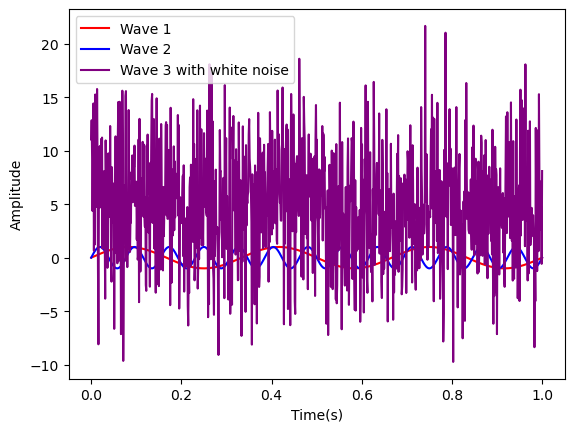

In [38]:
import numpy as np
import math
import matplotlib.pyplot as plt

t = np.linspace(0 , 1 , 1000)
wave1 = np.sin(3 * 2 * (math.pi) * t)
wave2 = np.sin(13 * 2 * (math.pi) * t)
white_noise = (np.random.normal(5, 5, 1000))
wave3noisy = wave1 + wave2 + white_noise

plt.plot(t, wave1, label="Wave 1", color="Red")
plt.plot(t, wave2, label="Wave 2", color="Blue")
plt.plot(t, wave3noisy, label="Wave 3 with white noise", color="Purple")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()



The above plot shows the same waves from the beginning but is heavily obstructed by white noise that was randomly generated, making the original waves impossible to point out. This is useful to understand as this is similar to what LIGO researchers would see from completely unfiltered data, gravitational waves hidden in a pool of outside noise. 

<function matplotlib.pyplot.show(close=None, block=None)>

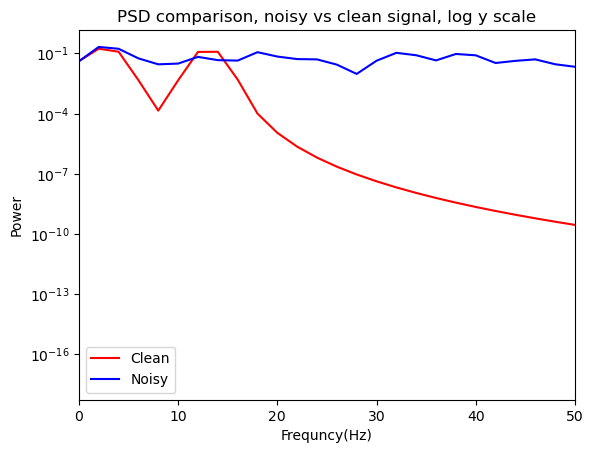

In [43]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.signal import welch

freqs , power = welch(wave3clean, 1000, nperseg = 500)
freqs_noise , power_noise = welch(wave3noisy, 1000, nperseg = 500)
plt.plot(freqs, power, label = "Clean", color="Red")
plt.plot(freqs_noise, power_noise, label = "Noisy", color = "Blue")
plt.xlabel("Frequncy(Hz)")
plt.xlim(0,50)
plt.yscale("log")
plt.ylabel("Power")
plt.title("PSD comparison, noisy vs clean signal, log y scale")
plt.legend()
plt.show

The flater blue line shows the white noise obscuring the waves we are looking for, while the clean rec line shows the peaks around 3 and 13 as expected.The signal spikes we see in red are invisible in blue because as we saw in the plot of the noisy wave 3, the peaks are drowned out.